In [3]:
import tensorflow as tf
import h5py
import numpy as np
import json

train_idx = np.load("../data/processed/train_idx.npy")
val_idx = np.load("../data/processed/val_idx.npy")
test_idx = np.load("../data/processed/test_idx.npy")
encoded_labels = np.load("../data/processed/encoded_labels.npy")

with open("../data/processed/class_weights.json") as f:
    class_weight_dict = {int(k): v for k, v in json.load(f).items()}

h5_path = "../data/raw/TheCycloneImageDataset/Cyclone_Images.h5"
num_classes = len(np.unique(encoded_labels))

In [4]:
class CycloneDataGeneratorTL(tf.keras.utils.Sequence):
    def __init__(self, h5_path, indices, labels, batch_size=32, shuffle=True):
        self.h5_path = h5_path
        self.indices = indices
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_indices_sorted = np.sort(batch_indices)

        with h5py.File(self.h5_path, 'r') as f:
            images = f['Images'][batch_indices_sorted].astype('float32')

        # 4 channels -> first 3 channels use karo (IR, WaterVapor, Visible)
        images = images[:, :, :, :3]

        # Resize 128x128 -> 224x224
        images = tf.image.resize(images, (224, 224))

        # ResNet's preprocessing (0-255 range expects, apna hai wahi hai already)
        images = tf.keras.applications.resnet50.preprocess_input(images)

        labels = self.labels[batch_indices_sorted]
        return images, labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen_tl = CycloneDataGeneratorTL(h5_path, train_idx, encoded_labels, batch_size=32)
val_gen_tl = CycloneDataGeneratorTL(h5_path, val_idx, encoded_labels, batch_size=32, shuffle=False)

print("Batches:", len(train_gen_tl))

Batches: 461


In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Pretrained ResNet50 load karo (bina top classification layer ke)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Pretrained layers ko FREEZE karo (abhi inko retrain nahi karna)
base_model.trainable = False

# Apna khud ka classification head upar add karo
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_tl.summary()

2026-09-01 00:25:14.666115: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-01 00:25:14.666134: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-01 00:25:14.666139: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-09-01 00:25:14.666150: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-01 00:25:14.666159: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
from tensorflow.keras.optimizers import Adam

model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history_tl = model_tl.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10


/Users/chessinorbit/Desktop/CYCLONE-PREDICTION/venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-09-01 00:25:16.471686: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


461/461 ━━━━━━━━━━━━━━━━━━━━ 124s 265ms/step - accuracy: 0.3333 - loss: 2.5675 - val_accuracy: 0.4455 - val_loss: 1.2900
Epoch 2/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 137s 297ms/step - accuracy: 0.3913 - loss: 2.3345 - val_accuracy: 0.4850 - val_loss: 1.2268
Epoch 3/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 144s 313ms/step - accuracy: 0.4071 - loss: 2.1981 - val_accuracy: 0.4908 - val_loss: 1.2167
Epoch 4/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 147s 318ms/step - accuracy: 0.4271 - loss: 1.9785 - val_accuracy: 0.5140 - val_loss: 1.1660
Epoch 5/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 148s 322ms/step - accuracy: 0.4374 - loss: 1.8630 - val_accuracy: 0.5348 - val_loss: 1.0853
Epoch 6/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 149s 324ms/step - accuracy: 0.4466 - loss: 1.7990 - val_accuracy: 0.5319 - val_loss: 1.0948
Epoch 7/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 150s 325ms/step - accuracy: 0.4626 - loss: 1.6758 - val_accuracy: 0.5360 - val_loss: 1.0994
Epoch 8/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 151s 328ms/step - accuracy: 0.4631 - loss: 1.62

In [8]:
# Base model ke last 20 layers ko unfreeze karo
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Bahut chhota learning rate use karo (kyunki ab pretrained weights bhi update ho rahe hain, careful rehna hai)
from tensorflow.keras.optimizers import Adam

model_tl.compile(
    optimizer=Adam(learning_rate=0.00001),   # 10x chhota pehle se
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model_tl.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 197s 421ms/step - accuracy: 0.4935 - loss: 1.2804 - val_accuracy: 0.5829 - val_loss: 0.9629
Epoch 2/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 194s 421ms/step - accuracy: 0.5429 - loss: 1.1061 - val_accuracy: 0.6116 - val_loss: 0.9131
Epoch 3/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 1090s 2s/step - accuracy: 0.5824 - loss: 0.9529 - val_accuracy: 0.6454 - val_loss: 0.8461
Epoch 4/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 12160s 26s/step - accuracy: 0.6279 - loss: 0.8238 - val_accuracy: 0.6680 - val_loss: 0.7969
Epoch 5/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 16675s 36s/step - accuracy: 0.6655 - loss: 0.7186 - val_accuracy: 0.6913 - val_loss: 0.7657
Epoch 6/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 1214s 3s/step - accuracy: 0.7043 - loss: 0.6180 - val_accuracy: 0.7191 - val_loss: 0.7179
Epoch 7/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 167s 362ms/step - accuracy: 0.7505 - loss: 0.5192 - val_accuracy: 0.7487 - val_loss: 0.6683
Epoch 8/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 182s 394ms/step - accuracy: 0.7881 - los

In [9]:
model_tl.save("../models/resnet_finetuned.h5")
print("Model saved successfully!")

Model saved successfully!


In [10]:
test_gen_tl = CycloneDataGeneratorTL(h5_path, test_idx, encoded_labels, batch_size=32, shuffle=False)

test_loss, test_accuracy = model_tl.evaluate(test_gen_tl)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.8249 - loss: 0.5201
Test Accuracy: 0.8249
Test Loss: 0.5201


98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step
                                  precision    recall  f1-score   support

                  Cyclonic Storm       0.77      0.78      0.78       483
                 Deep Depression       0.73      0.75      0.74       680
                      Depression       0.88      0.88      0.88      1133
Extremely Severe / Super Cyclone       0.93      0.89      0.91       129
           Severe Cyclonic Storm       0.82      0.80      0.81       400
      Very Severe Cyclonic Storm       0.86      0.86      0.86       311

                        accuracy                           0.82      3136
                       macro avg       0.83      0.83      0.83      3136
                    weighted avg       0.83      0.82      0.83      3136



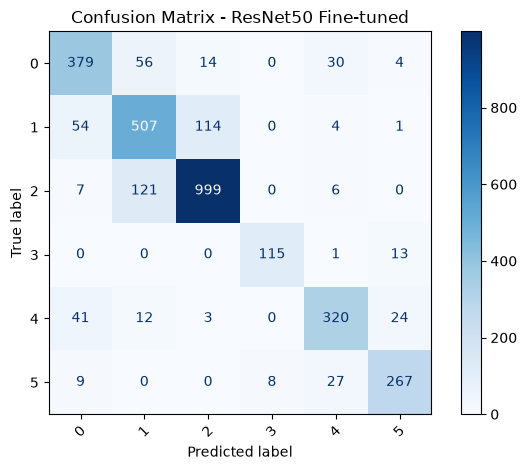

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predictions nikaalo test set pe
test_preds = model_tl.predict(test_gen_tl)
test_pred_classes = np.argmax(test_preds, axis=1)

# True labels ko EXACTLY usi order me nikaalo jis order me generator images deta hai
true_labels = []
for i in range(len(test_gen_tl)):
    _, batch_labels = test_gen_tl[i]
    true_labels.extend(batch_labels)
true_labels = np.array(true_labels)

# Classification report
with open("../data/processed/category_mapping.json") as f:
    mapping = json.load(f)
category_names = [mapping["int_to_category"][str(i)] for i in range(len(mapping["int_to_category"]))]

print(classification_report(true_labels, test_pred_classes, target_names=category_names))

# Confusion matrix plot
cm = confusion_matrix(true_labels, test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(len(category_names)))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - ResNet50 Fine-tuned")
plt.tight_layout()
plt.show()